5.3 비용 최소화하기 

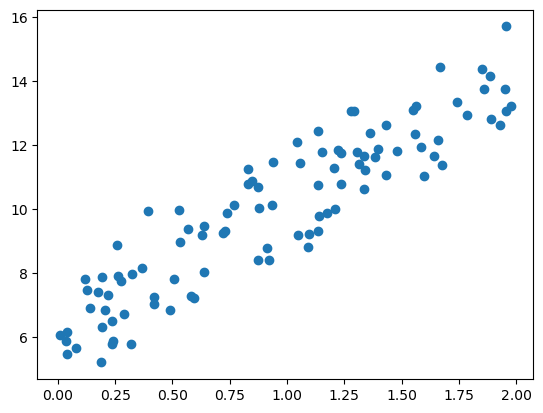

In [1]:
# 경사 하강법을 파이썬 코드로 구현하기
# y=4X+6 을 근사하기 위해 100개의 데이터 세트

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
# y=4x+6 을 근사 (w=1, 2=0.6). 임의의 값은 노이즈를 위해 만듦.
X=2*np.random.rand(100,1)
y=6+4*X+np.random.randn(100,1)

# X, y 데이터 세트 산점도로 시각화
plt.scatter(X,y)

In [2]:
# 비용함수 계산하기

def get_cost(y, y_pred):
    N= len(y)
    cost=np.sum(np.square(y-y_pred))/N
    return cost

In [3]:
# w1 과 w0 를 업데이트 할 w1_update, w0_update를 반환. 
def get_weight_updates(w1, w0, X, y, learning_rate=0.01):
    N = len(y)
    # 먼저 w1_update, w0_update를 각각 w1, w0의 shape와 동일한 크기를 가진 0 값으로 초기화
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)
    # 예측 배열 계산하고 예측과 실제 값의 차이 계산
    y_pred = np.dot(X, w1.T) + w0
    diff = y-y_pred
         
    # w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성 
    w0_factors = np.ones((N,1))

    # w1과 w0을 업데이트할 w1_update와 w0_update 계산
    w1_update = -(2/N)*learning_rate*(np.dot(X.T, diff))
    w0_update = -(2/N)*learning_rate*(np.dot(w0_factors.T, diff))    
    
    return w1_update, w0_update

In [4]:
# 입력 인자 iters로 주어진 횟수만큼 반복적으로 w1과 w0를 업데이트 적용함.

def gradient_descent_steps(X,y, iters=10000):
    # w0와 w1을 모두 0으로 초기화.
    w0=np.zeros((1,1))
    w1=np.zeros((1,1))

    # 인자로 주어진 iters 만큼 반복적으로 get_weight_updates() 호출해 w1, w0 업데이트 수행.
    for ind in range(iters):
        w1_update, w0_update=get_weight_updates(w1,w0,X,y,learning_rate=0.01)
        w1=w1-w1_update
        w0=w0-w0_update

    return w1,w0

In [5]:
# 예측값과 실제값의 RSS 차이를 계산하는 get_cost()

def get_cost(y, y_pred):
    N = len(y) 
    cost = np.sum(np.square(y - y_pred))/N
    return cost

w1, w0 = gradient_descent_steps(X, y, iters=1000)
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0,0], w0[0,0]))
y_pred = w1[0,0] * X + w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1:4.022 w0:6.162
Gradient Descent Total Cost:0.9935


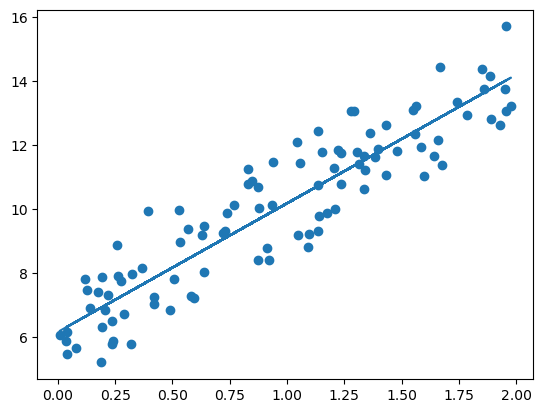

In [6]:
# y_pred에 기반한 회귀선 구하기

plt.scatter(X, y)
plt.plot(X,y_pred)

In [7]:
# 전체 X,y 데이터에서 랜덤하게 batch_size만큼 데이터를 추출해 update 값 계산하기

def stochastic_gradient_descent_steps(X, y, batch_size=10, iters=1000):
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    prev_cost = 100000
    iter_index =0
    
    for ind in range(iters):
        np.random.seed(ind)
        # 전체 X, y 데이터에서 랜덤하게 batch_size만큼 데이터 추출하여 sample_X, sample_y로 저장
        stochastic_random_index = np.random.permutation(X.shape[0])
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]
        # 랜덤하게 batch_size만큼 추출된 데이터 기반으로 w1_update, w0_update 계산 후 업데이트
        w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
    
    return w1, w0

In [12]:
# w1과 w0 예측 오류 비용 계산하기

w1, w0 = stochastic_gradient_descent_steps(X, y, iters=1000)
print("w1:",round(w1[0,0],3),"w0:",round(w0[0,0],3))
y_pred = w1[0,0] * X + w0
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1: 4.028 w0: 6.156
Stochastic Gradient Descent Total Cost:0.9937


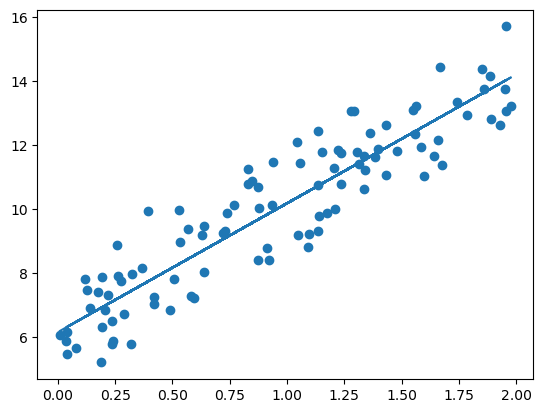

In [13]:
# y_pred에 기반한 회귀선 구하기

plt.scatter(X, y)
plt.plot(X,y_pred)

In [14]:
# 1. 일반 경사 하강법 (Batch GD) - 비용 기록 버전
def gd_steps_with_history(X, y, iters=1000):
    w0, w1 = np.zeros((1,1)), np.zeros((1,1))
    cost_history = [] # 비용 저장용
    
    for i in range(iters):
        w1_up, w0_up = get_weight_updates(w1, w0, X, y, learning_rate=0.01)
        w1, w0 = w1 - w1_up, w0 - w0_up
        cost_history.append(get_cost(y, np.dot(X, w1.T) + w0))
    return cost_history

# 2. 확률적 경사 하강법 (SGD) - 비용 기록 버전
def sgd_steps_with_history(X, y, batch_size=10, iters=1000):
    w0, w1 = np.zeros((1,1)), np.zeros((1,1))
    cost_history = []
    
    for i in range(iters):
        indices = np.random.permutation(X.shape[0])
        sample_X, sample_y = X[indices[:batch_size]], y[indices[:batch_size]]
        w1_up, w0_up = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
        w1, w0 = w1 - w1_up, w0 - w0_up
        cost_history.append(get_cost(y, np.dot(X, w1.T) + w0))
    return cost_history

# 실행 및 데이터 수집
gd_history = gd_steps_with_history(X, y)
sgd_history = sgd_steps_with_history(X, y)

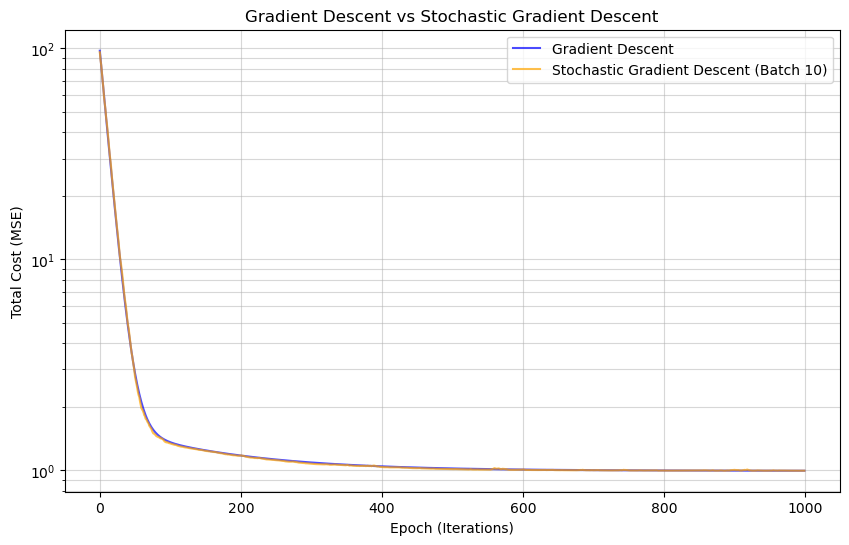

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(gd_history, label='Gradient Descent', color='blue', alpha=0.7)
plt.plot(sgd_history, label='Stochastic Gradient Descent (Batch 10)', color='orange', alpha=0.7)

plt.xlabel('Epoch (Iterations)')
plt.ylabel('Total Cost (MSE)')
plt.title('Gradient Descent vs Stochastic Gradient Descent')
plt.yscale('log') # 초기 오차가 커서 로그 스케일로 보면 더 잘 보입니다.
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

5.4 사이킷런 LinearRegression을 이용한 보스턴 주택 가격 예측

In [9]:
# LinearRegression 클래스 설정하기

from sklearn.linear_model import LinearRegression

lr = LinearRegression(fit_intercept=True, copy_X=True, n_jobs=1)

In [10]:
# LinearRegression을 이용해 보스턴 주택 가격 회귀 구현
# 을 하려했으나, sklearn 버전이 달라서 킬리포니아로 변경해서 진행

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing
import warnings

warnings.filterwarnings('ignore')

# california 데이터셋 로드
california = fetch_california_housing()

# DataFrame 변환
housingDF = pd.DataFrame(california.data, columns=california.feature_names)

# target 추가
housingDF['PRICE'] = california.target

print('California 데이터셋 크기 :', housingDF.shape)
housingDF.head()

California 데이터셋 크기 : (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


KeyboardInterrupt: 

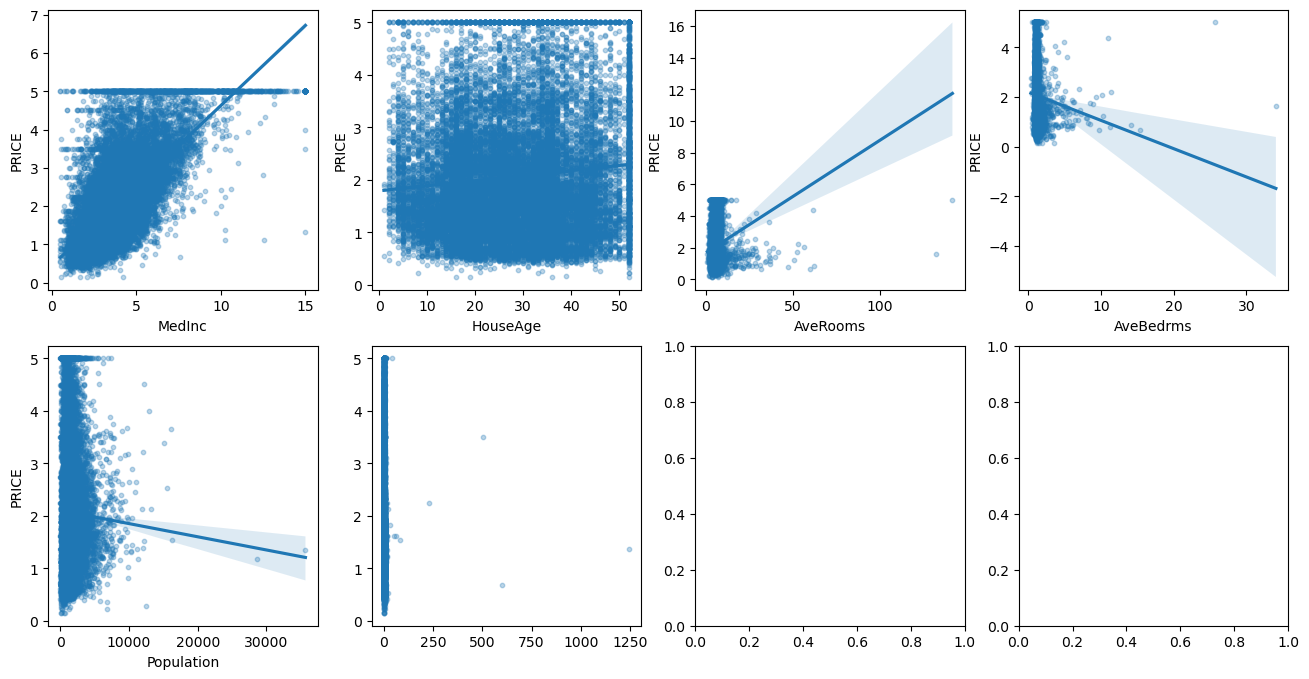

In [11]:
# 2행 4열 subplot 생성
fig, axs = plt.subplots(figsize=(16, 8), ncols=4, nrows=2)

lm_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms','Population', 'AveOccup', 'Latitude', 'Longitude']

for i, feature in enumerate(lm_features):
    row = i // 4
    col = i % 4
    # 산점도 + 선형회귀선
    sns.regplot(x=feature, y='PRICE', data=housingDF, ax=axs[row][col], scatter_kws={'alpha':0.3, 's':10})

fig.tight_layout()

fig.savefig('california_housing_regplots.tif', format='tif', dpi=300, bbox_inches='tight')

In [ ]:
# 캘리포니아의 학습과 예측 그리고 평가

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = housingDF['PRICE']
X_data = housingDF.drop(['PRICE'], axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_target, test_size=0.3, random_state=156)

# Linear Regression OLS로 학습/예측/평가 수행
lr = LinearRegression()
lr.fit(X_train, y_train)
y_preds = lr.predict(X_test)

mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f} , RMSE : {1:.3f}'.format(mse, rmse))
print('Variance score : {0:.3f}'.format(r2_score(y_test, y_preds)))

MSE : 0.543 , RMSE : 0.737
Variance score : 0.595


In [ ]:
# 회귀 값 보기

print('절편 값:',lr.intercept_)
print('회귀 계수값:', np.round(lr.coef_, 1))

절편 값: -37.239053052941564
회귀 계수값: [ 0.4  0.  -0.1  0.6 -0.  -0.  -0.4 -0.4]


In [ ]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. index가 칼럼명에 유의

coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns )
coeff.sort_values(ascending=False)

AveBedrms     0.6
MedInc        0.4
HouseAge      0.0
Population   -0.0
AveOccup     -0.0
AveRooms     -0.1
Latitude     -0.4
Longitude    -0.4
dtype: float64

In [ ]:
# 변환된 MSE 값에 sqrt() 함수를 적용해 RSME 추출

from sklearn.model_selection import cross_val_score

y_target = housingDF['PRICE']
X_data = housingDF.drop(['PRICE'],axis=1,inplace=False)
lr = LinearRegression()

# cross_val_score( )로 5 Fold 셋으로 MSE 를 구한 뒤 이를 기반으로 다시  RMSE 구함. 
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv = 5)
rmse_scores  = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring="neg_mean_squared_error")로 반환된 값은 모두 음수 
print(' 5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print(' 5 folds 의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print(' 5 folds 의 평균 RMSE : {0:.3f} '.format(avg_rmse))

 5 folds 의 개별 Negative MSE scores:  [-0.48 -0.62 -0.65 -0.54 -0.49]
 5 folds 의 개별 RMSE scores :  [0.7  0.79 0.8  0.74 0.7 ]
 5 folds 의 평균 RMSE : 0.746 


5.5 다항 회귀와 과(대)적합/과소적합 이해

In [ ]:
# 다항회귀

from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 다항식으로 변환한 단항식 생성, [[0,1],[2,3]]의 2X2 행렬 생성
X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature:\n',X )

# degree = 2 인 2차 다항식으로 변환하기 위해 PolynomialFeatures를 이용하여 변환
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 feature:\n', poly_ftr)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 feature:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [ ]:
# 3차 다항 회귀 함수

def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    print(X[:, 0])
    print(X[:, 1])
    return y

X = np.arange(0,4).reshape(2,2)

print('일차 단항식 계수 feature: \n' ,X)
y = polynomial_func(X)
print('삼차 다항식 결정값: \n', y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
[0 2]
[1 3]
삼차 다항식 결정값: 
 [  5 125]


In [ ]:
# 선형회귀에 적용
# 3 차 다항식 변환 
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n',poly_ftr)

# Linear Regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr,y)
print('Polynomial 회귀 계수\n' , np.round(model.coef_, 2))
print('Polynomial 회귀 Shape :', model.coef_.shape)

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [-0.    0.18  0.18  0.36  0.54  0.72  0.72  1.08  1.62  2.34]
Polynomial 회귀 Shape : (10,)


In [ ]:
# 사이킷런의 pipeline 객체를 이용해 한 번에 다항 회귀 구현하기

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3 
    return y

# Pipeline 객체로 Streamline 하게 Polynomial Feature변환과 Linear Regression을 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('linear', LinearRegression())])
X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X, y)
print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_, 2))

Polynomial 회귀 계수
 [-0.    0.18  0.18  0.36  0.54  0.72  0.72  1.08  1.62  2.34]


다항 회귀를 이용한 과소적합 및 과적합 이해

In [ ]:
# cosine 곡선에 약간의 noise 삽입하기


import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

# 임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환.
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

# X는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터입니다.
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

# y 값은 코사인 기반의 true_fun()에서 약간의 노이즈 변동 값을 더한 값입니다.
y = true_fun(X) + np.random.randn(n_samples) * 0.1

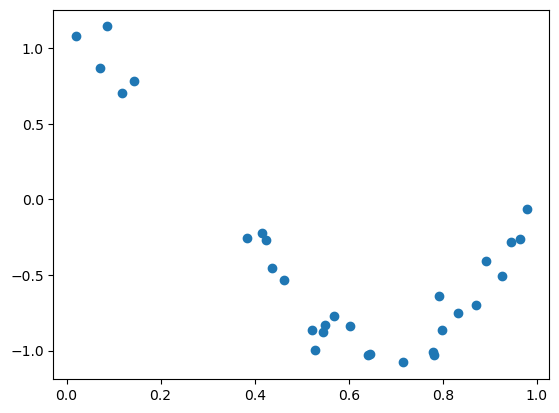

In [ ]:
# 현재 상태에서의 시각화
plt.scatter(X, y)


Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE 는 0.40772896250986845 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE 는 0.04320874987231737 입니다.

Degree 15 회귀 계수는 [-2.98293000e+03  1.03899370e+05 -1.87416114e+06  2.03716252e+07
 -1.44873341e+08  7.09315818e+08 -2.47066009e+09  6.24561742e+09
 -1.15676664e+10  1.56895176e+10 -1.54006289e+10  1.06457467e+10
 -4.91378551e+09  1.35919950e+09 -1.70381195e+08] 입니다.
Degree 15 MSE 는 182618860.9149443 입니다.


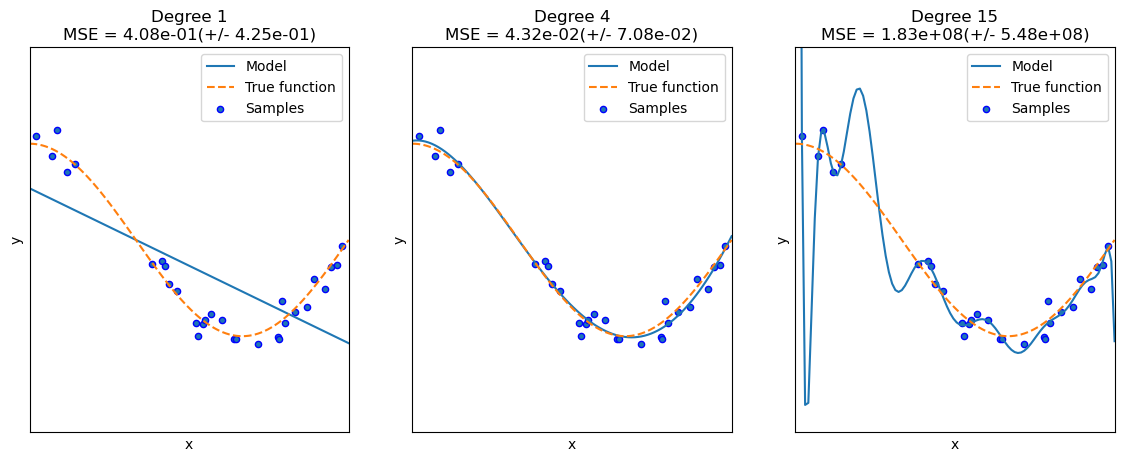

In [ ]:
# 차수를 변화시켜보기

plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

# 다항 회귀의 차수(degree)를 1, 4, 15로 각각 변화시키면서 비교합니다.
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())
    
    # 개별 degree별로 Polynomial 변환합니다.
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X.reshape(-1, 1), y)
    
    # 교차 검증으로 다항 회귀를 평가합니다.
    scores = cross_val_score(pipeline, X.reshape(-1, 1), y, scoring="neg_mean_squared_error", cv=10)
    # Pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 이용해 회귀계수 추출
    coefficients = pipeline.named_steps['linear_regression'].coef_
    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE 는 {1} 입니다.'.format(degrees[i], -1*np.mean(scores)))
          
    # 0 부터 1까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다.
    # 테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교합니다.
    X_test = np.linspace(0, 1, 100)
    # 예측값 곡선
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    # 실제 값 곡선
    plt.plot(X_test, true_fun(X_test), '--', label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x"); plt.ylabel("y"); plt.xlim((0, 1)); plt.ylim((-2, 2)); plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std()))
    
plt.show()